In [1]:
import time
import h5py
import shutil
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from chemrixs.average import Average
from chemrixs.smalldata import SmallData
from chemrixs.process import Reduced
from chemrixs.utils import *
from pathlib import Path
%matplotlib widget 

In [ ]:
os.makedirs('proc', exist_ok=True)
os.makedirs('avg', exist_ok=True)
os.makedirs('figs', exist_ok=True)

In [ ]:
base_folder =  '/sdf/data/lcls/ds/rix/'
raw_path = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run'

[112. 193. 202. 202. 202. 208. 209. 200. 202. 196. 206. 199. 197. 207.
 205. 205. 208. 197. 201. 203. 197. 195. 200. 206. 205. 189. 200. 200.
 189. 195. 202. 191. 193. 204. 193. 194. 196. 194. 189.]
[339. 392. 404. 407. 415. 416. 402. 408. 403. 396. 402. 401. 412. 409.
 407. 406. 413. 392. 402. 403. 400. 404. 395. 401. 406. 377. 401. 398.
 389. 391. 405. 384. 382. 400. 385. 390. 390. 390. 383.]
[501. 589. 616. 614. 610. 626. 607. 610. 604. 601. 605. 599. 625. 616.
 608. 605. 614. 589. 605. 604. 600. 606. 594. 600. 607. 574. 596. 593.
 583. 588. 616. 579. 571. 595. 574. 589. 579. 585. 584.]
[671. 794. 813. 819. 814. 836. 806. 809. 807. 804. 815. 808. 820. 820.
 808. 810. 813. 791. 806. 808. 803. 805. 788. 800. 807. 769. 794. 799.
 771. 786. 812. 774. 762. 796. 769. 785. 774. 772. 777.]
[ 833. 1000. 1020. 1023. 1017. 1045. 1002. 1019. 1018. 1001. 1014. 1012.
 1005.  967. 1018. 1012. 1011.  993. 1007. 1011.  999. 1004.  989.  996.
 1009.  960.  996.  998.  964.  985. 1005.  972.  961.  99

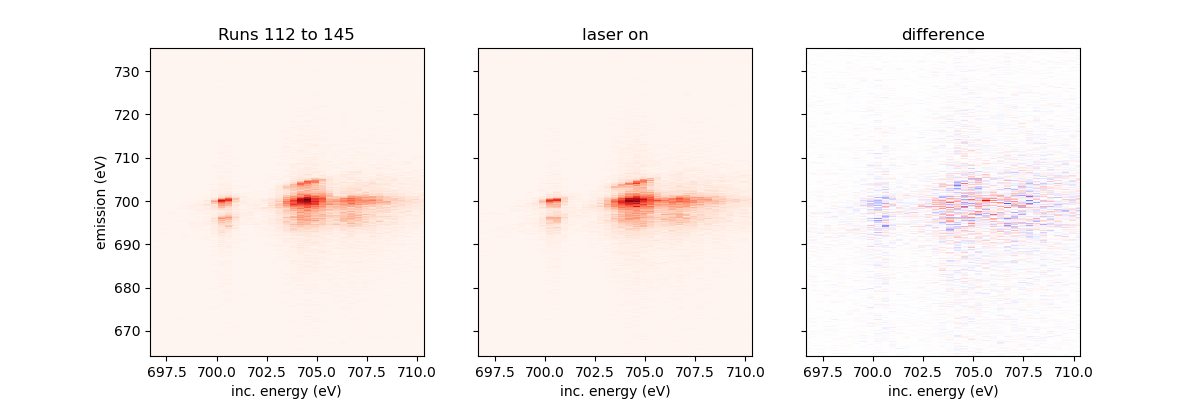

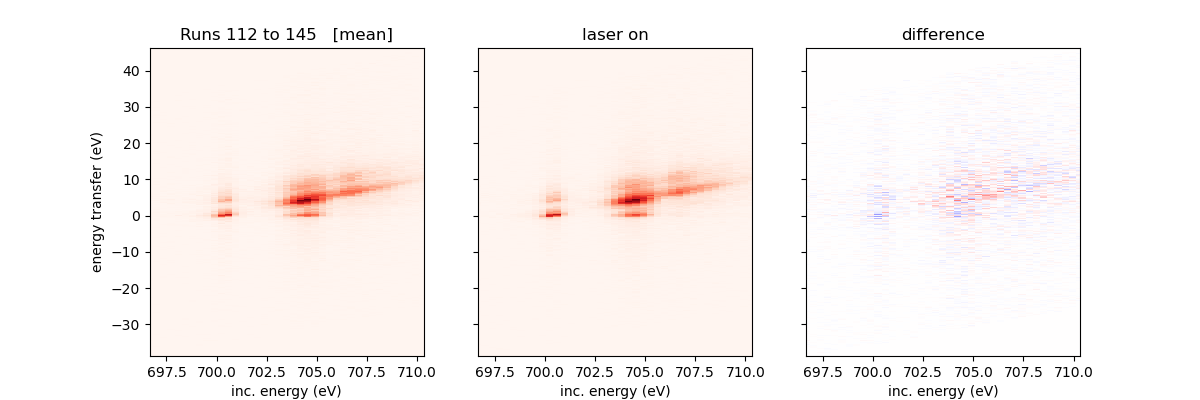

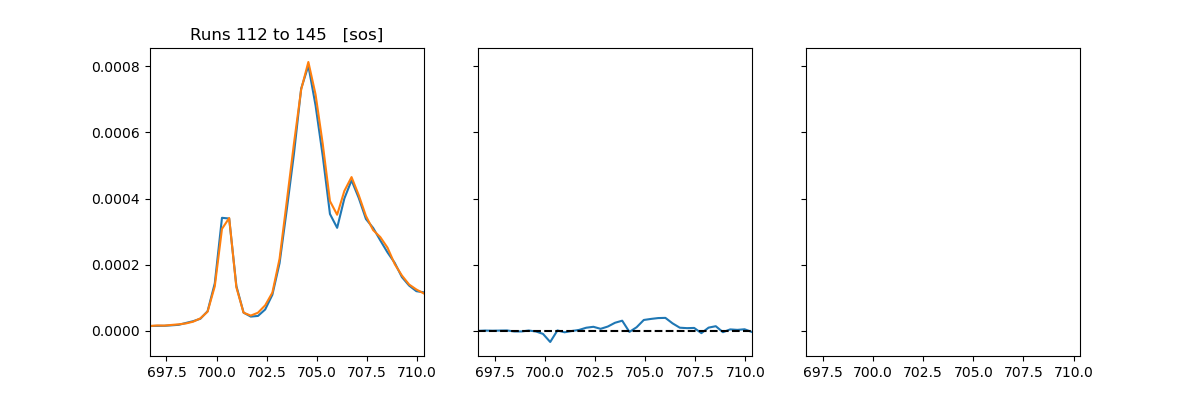

In [7]:
base_folder =  '/sdf/data/lcls/ds/rix/'
proc_folder = './proc/'


# bgrun = 86 #shift2
bgrun = 86 #shift3
# bgrun = 191 #shift4
# runs = [112]
# runs = [45,46]
# runs=[112,114,115,116,117,118,119,120,121,122,123,127,129,]
# runs = [138,139,140,141,145]
# runs = [112,114,115,116,117,118,119,120,121,122,123,127,129,138,139,140,141,142,145]
runs = [112,114,115,116,118,138,139,140,145]
# runs = [112,114,115,116]
# runs = [178,179,180,181,182,183,184,185,186,188]
# runs = [226]

##################### meopy below

# runs = [178,179,180,181,182,183,184,185,186,188,226,227,228,233,234,235,236,237,238,248,249,250]
# runs = [226]
        
# runs = [226,227,228,233,234,235,236,237,238,248,249,250]


exp = 'rix101231825'


fyaml = '../roi_input.yml'

bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'
bgyaml = '../BGroi_input.yml'

avg = Average(runs, proc_path = 'proc/Run', avg = 'mean', output_path = f'avg/{runs[0]}_to_{runs[-1]}.h5',
             raw_path = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run' , bgpath = bgname, fyaml=fyaml, bgyaml=bgyaml, 
             save= True,norm = True)

avg.plot_svls2D(figsize=(12,4),savefig=False)
avg.plot_svls2D_ET(figsize=(12,4),savefig=False)
avg.plot_svls1D(figsize=(12,4),mode='sos')

=== Keys in proc/Run0140.h5 ===
  axis_svls_off_mean                                 shape=(39, 796)
  axis_svls_off_std                                  shape=(39, 796)
  axis_svls_off_sum                                  shape=(39, 796)
  axis_svls_off_sumI0                                shape=(39,)
  axis_svls_off_sumSV                                shape=(39, 796)
  axis_svls_on_mean                                  shape=(39, 796)
  axis_svls_on_std                                   shape=(39, 796)
  axis_svls_on_sum                                   shape=(39, 796)
  axis_svls_on_sumI0                                 shape=(39,)
  axis_svls_on_sumSV                                 shape=(39, 796)
  counts_off                                         shape=(39,)
  counts_on                                          shape=(39,)
  scanvar_off                                        shape=(39,)
  scanvar_on                                         shape=(39,)

✓ all new keys present

s

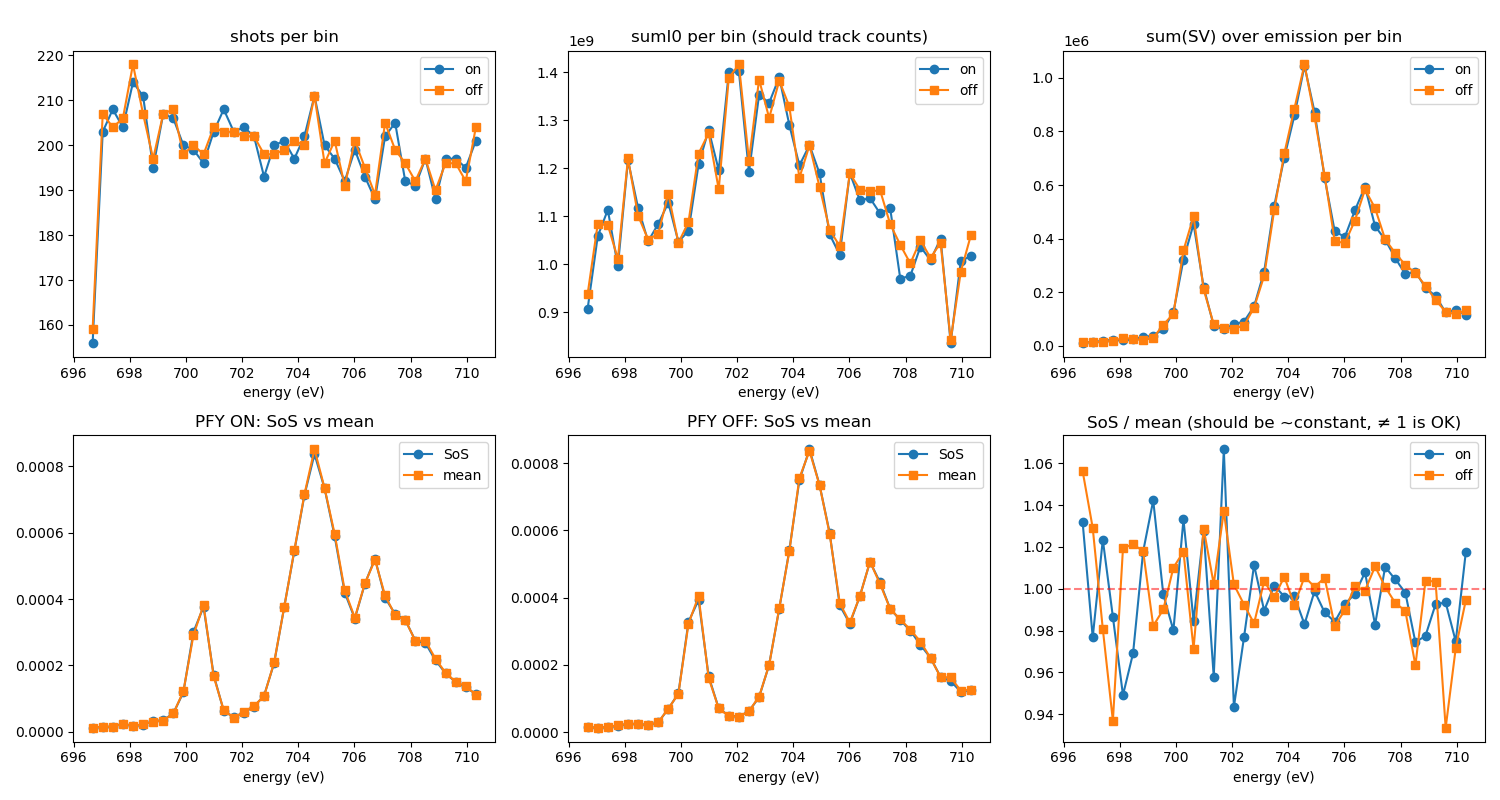


ratio mean: on=0.996  off=0.998
ratio std:  on=0.0245  off=0.0232


In [9]:
import h5py, numpy as np, matplotlib.pyplot as plt

run = 140
proc_file = f'proc/Run{run:04d}.h5'

with h5py.File(proc_file, 'r') as f:
    keys = sorted(f.keys())
    
    # ---- 1. Verify new keys are saved ----
    print(f'=== Keys in {proc_file} ===')
    for k in keys:
        print(f'  {k:50s} shape={f[k].shape}')
    
    needed = ['axis_svls_on_sumSV','axis_svls_off_sumSV',
              'axis_svls_on_sumI0','axis_svls_off_sumI0']
    missing = [k for k in needed if k not in keys]
    if missing:
        raise RuntimeError(f'MISSING from proc file: {missing}  '
                           f'(delete proc/Run{run:04d}.h5 and re-reduce)')
    print('\n✓ all new keys present\n')
    
    # ---- 2. Load and compare ----
    scanvar_on  = f['scanvar_on'][:]
    scanvar_off = f['scanvar_off'][:]
    sumSV_on  = f['axis_svls_on_sumSV'][:]
    sumSV_off = f['axis_svls_off_sumSV'][:]
    sumI0_on  = f['axis_svls_on_sumI0'][:]
    sumI0_off = f['axis_svls_off_sumI0'][:]
    mean_on   = f['axis_svls_on_mean'][:]
    mean_off  = f['axis_svls_off_mean'][:]
    counts_on  = f['counts_on'][:]
    counts_off = f['counts_off'][:]

print(f'scanvar_on  shape={scanvar_on.shape}    sumSV_on shape={sumSV_on.shape}   sumI0_on shape={sumI0_on.shape}')
print(f'scanvar_off shape={scanvar_off.shape}   sumSV_off shape={sumSV_off.shape}  sumI0_off shape={sumI0_off.shape}')
print(f'mean_on shape={mean_on.shape}    counts_on shape={counts_on.shape}')

# ---- 3. Two PFY estimators (should give the same shape) ----
PFY_sos_on   = sumSV_on.sum(axis=1) / sumI0_on
PFY_sos_off  = sumSV_off.sum(axis=1) / sumI0_off
PFY_mean_on  = mean_on.sum(axis=1)
PFY_mean_off = mean_off.sum(axis=1)

fig, axs = plt.subplots(2, 3, figsize=(15, 8))

# Row 1: components of the SoS path
axs[0,0].plot(scanvar_on, counts_on, 'o-', label='on');  axs[0,0].plot(scanvar_off, counts_off, 's-', label='off')
axs[0,0].set_title('shots per bin');  axs[0,0].legend()

axs[0,1].plot(scanvar_on, sumI0_on, 'o-', label='on');   axs[0,1].plot(scanvar_off, sumI0_off, 's-', label='off')
axs[0,1].set_title('sumI0 per bin (should track counts)');  axs[0,1].legend()

axs[0,2].plot(scanvar_on,  sumSV_on.sum(axis=1),  'o-', label='on')
axs[0,2].plot(scanvar_off, sumSV_off.sum(axis=1), 's-', label='off')
axs[0,2].set_title('sum(SV) over emission per bin');  axs[0,2].legend()

# Row 2: SoS vs mean comparison
axs[1,0].plot(scanvar_on, PFY_sos_on,  'o-', label='SoS')
axs[1,0].plot(scanvar_on, PFY_mean_on, 's-', label='mean')
axs[1,0].set_title('PFY ON: SoS vs mean');  axs[1,0].legend()

axs[1,1].plot(scanvar_off, PFY_sos_off,  'o-', label='SoS')
axs[1,1].plot(scanvar_off, PFY_mean_off, 's-', label='mean')
axs[1,1].set_title('PFY OFF: SoS vs mean');  axs[1,1].legend()

# Ratio — should be approximately constant if both methods are correct
with np.errstate(divide='ignore', invalid='ignore'):
    ratio_on  = PFY_sos_on  / PFY_mean_on
    ratio_off = PFY_sos_off / PFY_mean_off
axs[1,2].plot(scanvar_on,  ratio_on,  'o-', label='on')
axs[1,2].plot(scanvar_off, ratio_off, 's-', label='off')
axs[1,2].axhline(1.0, ls='--', color='red', alpha=0.5)
axs[1,2].set_title('SoS / mean (should be ~constant, ≠ 1 is OK)')
axs[1,2].legend()

for ax in axs.ravel(): ax.set_xlabel('energy (eV)')
plt.tight_layout(); plt.show()

print(f'\nratio mean: on={np.nanmean(ratio_on):.3g}  off={np.nanmean(ratio_off):.3g}')
print(f'ratio std:  on={np.nanstd(ratio_on):.3g}  off={np.nanstd(ratio_off):.3g}')

[116. 204. 202. 203. 203. 214. 200. 206. 201. 204. 138. 104. 141. 192.
 205. 210. 194. 213. 203. 200. 198. 202. 196. 195. 214. 192. 197. 197.
 192. 199. 192. 202. 193. 202. 190. 191. 198. 197. 199.]
[284. 415. 404. 410. 408. 417. 411. 403. 403. 411. 335. 309. 340. 394.
 409. 419. 391. 421. 407. 398. 398. 403. 392. 402. 417. 386. 394. 394.
 382. 398. 390. 399. 396. 395. 378. 391. 392. 393. 399.]
[437. 623. 601. 612. 617. 636. 602. 608. 608. 616. 530. 508. 546. 591.
 612. 631. 590. 627. 603. 601. 604. 607. 592. 597. 616. 579. 591. 604.
 576. 597. 584. 594. 589. 589. 573. 588. 587. 587. 600.]
[654. 827. 808. 815. 831. 836. 795. 822. 814. 821. 724. 707. 754. 790.
 820. 845. 783. 827. 801. 804. 805. 811. 790. 795. 821. 770. 789. 798.
 767. 808. 774. 796. 783. 785. 764. 790. 780. 782. 797.]
[ 809. 1035. 1020. 1016. 1033. 1050.  992. 1028. 1014. 1036.  915.  903.
  962.  999. 1021. 1050.  981. 1031. 1002. 1007. 1007. 1011.  986.  990.
 1031.  959.  996.  989.  961. 1007.  968.  999.  974.  98

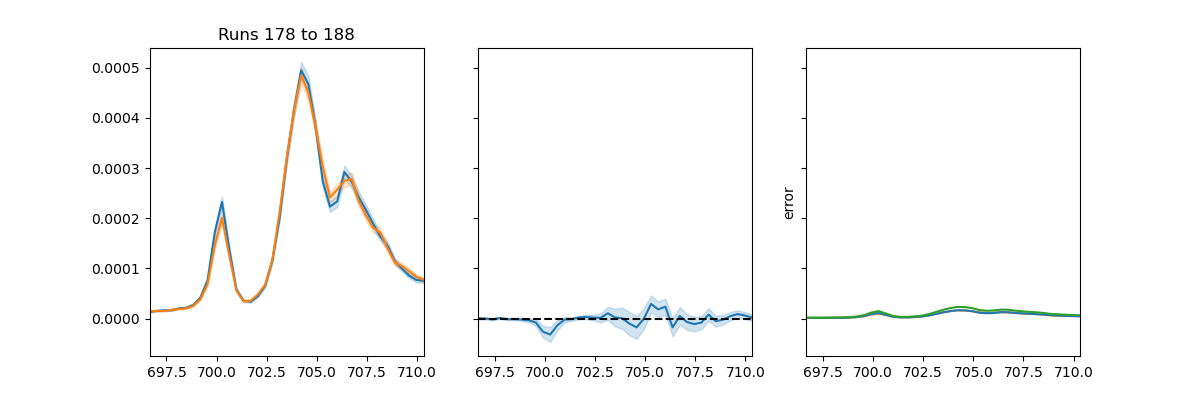

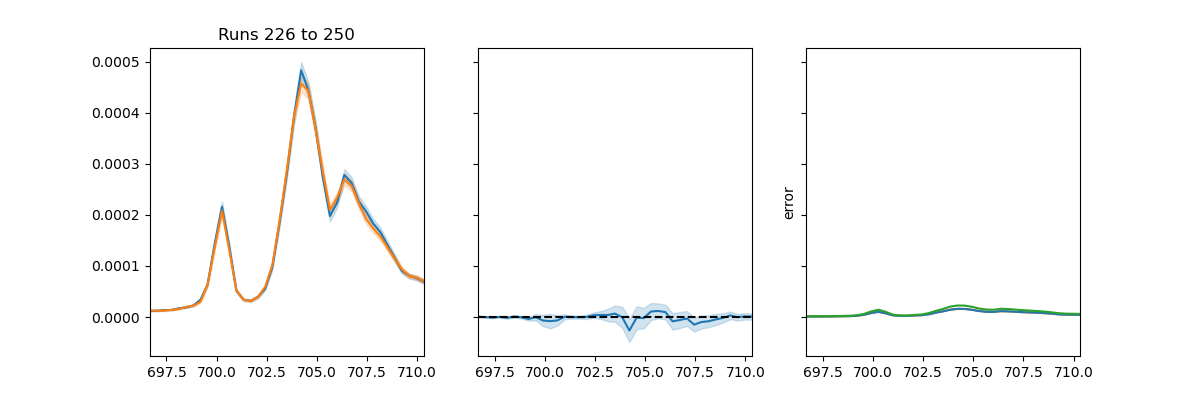

In [11]:
runs_shift3 = [178, 179, 180, 181, 182, 183, 184, 185, 186, 188]
runs_shift4 = [226, 227, 228, 233, 234, 235, 236, 237, 238, 248, 249, 250]

# Verify each group matches exactly one emi_calib and mono_calib row before processing
def matching_rows(runs, rows):
    return [(i, r) for i, r in enumerate(rows)
            if all(rn > r[0] and rn < r[1] for rn in runs)]

# print('shift 3:')
# print('  emi_calib  →', matching_rows(runs_shift3, cfg['emi_calib']))
# print('  mono_calib →', matching_rows(runs_shift3, cfg['mono_calib']))
# print('shift 4:')
# print('  emi_calib  →', matching_rows(runs_shift4, cfg['emi_calib']))
# print('  mono_calib →', matching_rows(runs_shift4, cfg['mono_calib']))

# Then process each separately
avg_s3 = Average(runs_shift3, proc_path='proc/Run', avg='mean',
                 output_path=f'avg/{runs_shift3[0]}_to_{runs_shift3[-1]}.h5',
                 raw_path=f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run',
                 bgpath=bgname, fyaml=fyaml, bgyaml=bgyaml, save=True, norm=True)

avg_s4 = Average(runs_shift4, proc_path='proc/Run', avg='mean',
                 output_path=f'avg/{runs_shift4[0]}_to_{runs_shift4[-1]}.h5',
                 raw_path=f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run',
                 bgpath=bgname, fyaml=fyaml, bgyaml=bgyaml, save=True, norm=True)

avg_s3.plot_svls1D(figsize=(12,4))
avg_s4.plot_svls1D(figsize=(12,4))

In [24]:
base_folder = '/sdf/data/lcls/ds/rix/'
exp = 'rix101231825'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run0086.h5'
fyaml = '../roi_input.yml'
bgyaml = '../BGroi_input.yml'
RUN = 140
variant_tags = ['th60_tha455','th60_tha440','th70_tha455','th70_tha440',
                'th80_tha455','th80_tha440','th100_tha455','th100_tha440']
# variant_tags = ['th60_tha455','th60_tha440','th70_tha455','th70_tha440', 'th80_tha455']

os.makedirs('proc', exist_ok=True)
os.makedirs('avg', exist_ok=True)

avg_results = {}
for tag in variant_tags:
    print(f'\n===== {tag} =====')
    variant_h5  = f'{base_folder}/{exp}/hdf5/smalldata/run{RUN}_{tag}/{exp}_Run{RUN:04d}.h5'
    variant_dir = f'proc_variants/{tag}'
    os.makedirs(variant_dir, exist_ok=True)
    proc_file   = f'{variant_dir}/Run{RUN:04d}.h5'

    # reduce if not already done
    if not os.path.isfile(proc_file):
        Reduced(variant_h5, bgname, fyaml, bgyaml,
                save=True, scantype='mono_fly', norm=True)
        shutil.move(f'./proc/Run{RUN:04d}.h5', proc_file)
        print(f'  saved -> {proc_file}')

    # now Average can find it: proc_path + '0140.h5' = variant_dir/Run0140.h5
    avg = Average([RUN], proc_path=f'{variant_dir}/Run', avg='mean',
                  output_path=f'avg/{RUN}_{tag}.h5',
                  raw_path=f'{base_folder}/{exp}/hdf5/smalldata/run{RUN}_{tag}/{exp}_Run',
                  bgpath=bgname, fyaml=fyaml, bgyaml=bgyaml,
                  save=True, norm=True, scantype='mono_fly')
    avg_results[tag] = avg


===== th60_tha455 =====
proc_variants/th60_tha455/Run
[159. 207. 204. 206. 218. 207. 197. 207. 208. 198. 200. 198. 204. 203.
 203. 202. 202. 198. 198. 199. 201. 200. 211. 196. 201. 191. 201. 195.
 189. 205. 199. 196. 192. 197. 190. 196. 196. 192. 204.]

===== th60_tha440 =====
proc_variants/th60_tha440/Run
[158. 207. 204. 206. 218. 207. 197. 207. 208. 198. 200. 198. 204. 203.
 203. 202. 202. 198. 198. 199. 201. 200. 211. 196. 201. 191. 201. 195.
 189. 205. 199. 196. 192. 197. 190. 196. 196. 192. 204.]

===== th70_tha455 =====
proc_variants/th70_tha455/Run
[158. 207. 204. 206. 218. 207. 197. 207. 208. 198. 200. 198. 204. 203.
 203. 202. 202. 198. 198. 199. 201. 200. 211. 196. 201. 191. 201. 195.
 189. 205. 199. 196. 192. 197. 190. 196. 196. 192. 204.]

===== th70_tha440 =====
proc_variants/th70_tha440/Run
[157. 207. 204. 206. 218. 207. 197. 207. 208. 198. 200. 198. 204. 203.
 203. 202. 202. 198. 198. 199. 201. 200. 211. 196. 201. 191. 201. 195.
 189. 205. 199. 196. 192. 197. 190. 196. 

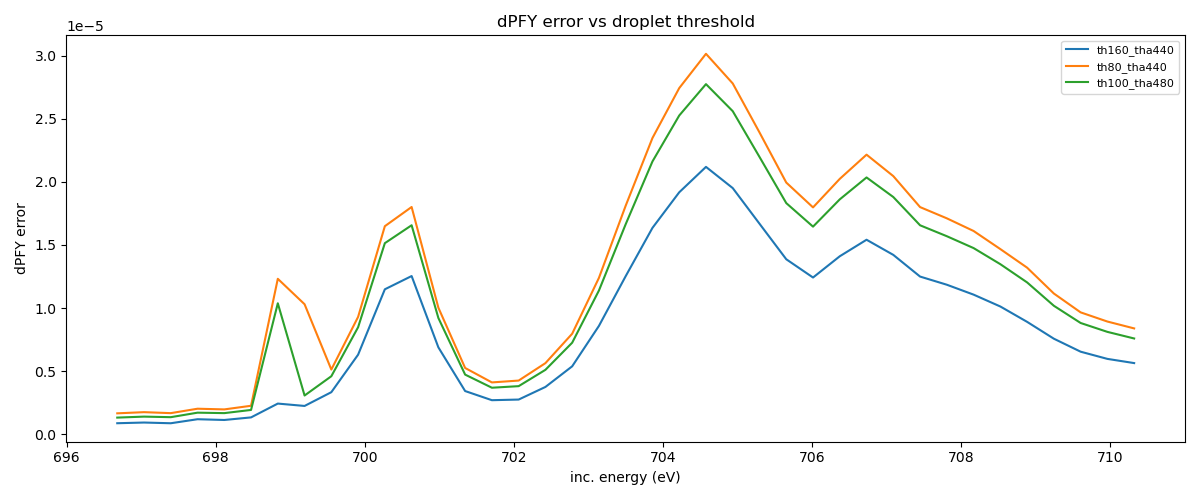

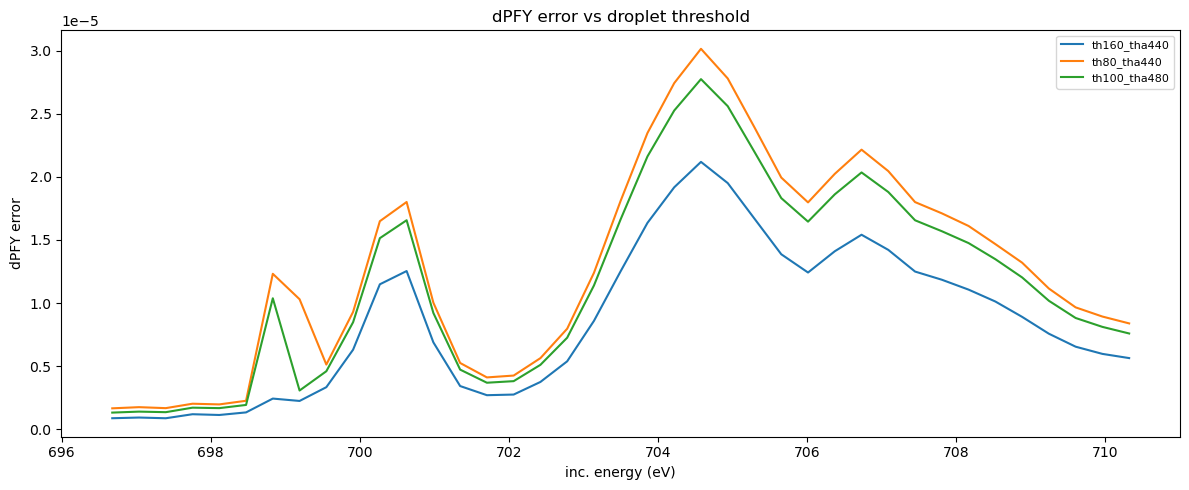

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def overlay_dPFYerr(avg_results, figsize=(12, 5)):
    """Overlay the dPFY error trace (sqrt(on_std^2 + off_std^2)) for each variant."""
    fig, ax = plt.subplots(figsize=figsize)

    for tag, avg in avg_results.items():
        a = avg.average
        # make sure PFYs exist (get_PFYs populates PFY_*_mean / PFY_*_std)
        if 'PFY_on_std' not in a:
            avg.get_PFYs()
            a = avg.average

        scanvar = a['scanvar_off']
        dPFYerr = np.sqrt(a['PFY_on_std']**2 + a['PFY_off_std']**2)
        ax.plot(scanvar, dPFYerr, label=tag)

    ax.set_xlabel('inc. energy (eV)')
    ax.set_ylabel('dPFY error')
    ax.set_title('dPFY error vs droplet threshold')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    return fig

overlay_dPFYerr(avg_results)

In [17]:
def plot_CEE(avg_results, emi_center, emi_width, use='off',
             plot_err=True, figsize=(12, 5)):
    """
    Constant Emission Energy cut overlay across variants.

    Sums (averages) the 2D RIXS map over [emi_center - emi_width/2,
    emi_center + emi_width/2] in emission energy, plots vs incident energy.

    Parameters
    ----------
    avg_results : dict {tag: Average}
    emi_center  : float, center of emission window (eV)
    emi_width   : float, full width of window (eV)
    use         : 'off', 'on', or 'diff' (laser-on minus laser-off)
    plot_err    : if True, shade ±std (propagated across summed pixels)
    """
    if use not in ('off', 'on', 'diff'):
        raise ValueError(f"use must be 'off', 'on', or 'diff', got {use!r}")

    fig, ax = plt.subplots(figsize=figsize)

    emi_lo = emi_center - emi_width / 2
    emi_hi = emi_center + emi_width / 2

    for tag, avg in avg_results.items():
        a = avg.average
        emi = avg.get_emi()
        emi_mask = (emi >= emi_lo) & (emi <= emi_hi)
        n_emi = emi_mask.sum()
        if n_emi == 0:
            print(f'  {tag}: NO pixels in emission window [{emi_lo}, {emi_hi}]')
            continue

        if use == 'diff':
            inc = np.asarray(a['scanvar_off'])
            Z_off = np.asarray(a['axis_svls_off_mean'])
            Z_on  = np.asarray(a['axis_svls_on_mean'])

            cee_off = np.nanmean(Z_off[:, emi_mask], axis=1)
            cee_on  = np.nanmean(Z_on[:,  emi_mask], axis=1)
            cee = cee_on - cee_off

            line, = ax.plot(inc, cee, label=f'{tag}  ({n_emi} px)')
            ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)

            # propagated error for the difference
            if (plot_err and 'axis_svls_off_std' in a
                    and 'axis_svls_on_std' in a):
                Zstd_off = np.asarray(a['axis_svls_off_std'])
                Zstd_on  = np.asarray(a['axis_svls_on_std'])
                err_off = np.sqrt(np.nansum(Zstd_off[:, emi_mask]**2, axis=1)) / n_emi
                err_on  = np.sqrt(np.nansum(Zstd_on[:,  emi_mask]**2, axis=1)) / n_emi
                cee_err = np.sqrt(err_off**2 + err_on**2)
                ax.fill_between(inc, cee - cee_err, cee + cee_err,
                                color=line.get_color(), alpha=0.2)
        else:
            inc = np.asarray(a[f'scanvar_{use}'])
            Z   = np.asarray(a[f'axis_svls_{use}_mean'])
            cee = np.nanmean(Z[:, emi_mask], axis=1)

            line, = ax.plot(inc, cee, label=f'{tag}  ({n_emi} px)')

            if plot_err and f'axis_svls_{use}_std' in a:
                Zstd = np.asarray(a[f'axis_svls_{use}_std'])
                cee_err = np.sqrt(np.nansum(Zstd[:, emi_mask]**2, axis=1)) / n_emi
                ax.fill_between(inc, cee - cee_err, cee + cee_err,
                                color=line.get_color(), alpha=0.2)

    ax.set_xlabel('inc. energy (eV)')
    if use == 'diff':
        ax.set_ylabel(f'ΔIntensity (on−off) at emi {emi_center}±{emi_width/2} eV')
        title_use = 'laser on − off'
    else:
        ax.set_ylabel(f'Intensity at emi {emi_center}±{emi_width/2} eV')
        title_use = f'laser {use}'
    ax.set_title(f'CEE cut — {title_use}, emi ∈ [{emi_lo:.2f}, {emi_hi:.2f}] eV')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

from chemrixs.utils import emi2ET

def plot_CET(avg_results, ET_center, ET_width, use='off',
             plot_err=True, ETstep=0.05, figsize=(12, 5)):
    """
    Constant Energy Transfer cut overlay across variants.

    Regrids the (incident, emission) map onto a uniform (incident, ET) grid
    via emi2ET, then averages over [ET_center - ET_width/2,
    ET_center + ET_width/2], plots vs incident energy.

    Parameters
    ----------
    avg_results : dict {tag: Average}
    ET_center   : float, center of energy-transfer window (eV)
    ET_width    : float, full width of window (eV)
    use         : 'off', 'on', or 'diff' (laser-on minus laser-off)
    plot_err    : if True, shade ±propagated std band
    ETstep      : ET grid resolution (eV) passed to emi2ET
    """
    if use not in ('off', 'on', 'diff'):
        raise ValueError(f"use must be 'off', 'on', or 'diff', got {use!r}")

    fig, ax = plt.subplots(figsize=figsize)
    ET_lo = ET_center - ET_width / 2
    ET_hi = ET_center + ET_width / 2

    for tag, avg in avg_results.items():
        a = avg.average
        emi = avg.get_emi()

        if use == 'diff':
            mono_off, E_trans, Zoff_ET, Sigoff_ET = emi2ET(
                a['scanvar_off'], emi,
                a['axis_svls_off_mean'], a['axis_svls_off_std'], ETstep)
            mono_on, _, Zon_ET, Sigon_ET = emi2ET(
                a['scanvar_on'], emi,
                a['axis_svls_on_mean'], a['axis_svls_on_std'], ETstep)
            inc = mono_off
            ET_mask = (E_trans >= ET_lo) & (E_trans <= ET_hi)
            n_ET = ET_mask.sum()
            if n_ET == 0:
                print(f'  {tag}: NO ET points in [{ET_lo}, {ET_hi}]')
                continue

            cet_off = np.nanmean(Zoff_ET[:, ET_mask], axis=1)
            cet_on  = np.nanmean(Zon_ET[:,  ET_mask], axis=1)
            cet = cet_on - cet_off

            line, = ax.plot(inc, cet, label=f'{tag}  ({n_ET} ET bins)')
            ax.axhline(0, color='k', ls='--', lw=0.8, alpha=0.5)

            if plot_err:
                err_off = np.sqrt(np.nansum(Sigoff_ET[:, ET_mask]**2, axis=1)) / n_ET
                err_on  = np.sqrt(np.nansum(Sigon_ET[:,  ET_mask]**2, axis=1)) / n_ET
                cet_err = np.sqrt(err_off**2 + err_on**2)
                ax.fill_between(inc, cet - cet_err, cet + cet_err,
                                color=line.get_color(), alpha=0.2)
        else:
            mono, E_trans, Z_ET, Sig_ET = emi2ET(
                a[f'scanvar_{use}'], emi,
                a[f'axis_svls_{use}_mean'], a[f'axis_svls_{use}_std'], ETstep)
            ET_mask = (E_trans >= ET_lo) & (E_trans <= ET_hi)
            n_ET = ET_mask.sum()
            if n_ET == 0:
                print(f'  {tag}: NO ET points in [{ET_lo}, {ET_hi}]')
                continue

            cet = np.nanmean(Z_ET[:, ET_mask], axis=1)
            line, = ax.plot(mono, cet, label=f'{tag}  ({n_ET} ET bins)')

            if plot_err:
                cet_err = np.sqrt(np.nansum(Sig_ET[:, ET_mask]**2, axis=1)) / n_ET
                ax.fill_between(mono, cet - cet_err, cet + cet_err,
                                color=line.get_color(), alpha=0.2)

    ax.set_xlabel('inc. energy (eV)')
    if use == 'diff':
        ax.set_ylabel(f'ΔIntensity (on−off) at ET {ET_center}±{ET_width/2} eV')
        title_use = 'laser on − off'
    else:
        ax.set_ylabel(f'Intensity at ET {ET_center}±{ET_width/2} eV')
        title_use = f'laser {use}'
    ax.set_title(f'CET cut — {title_use}, ET ∈ [{ET_lo:.2f}, {ET_hi:.2f}] eV')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


/lscratch/yzy25/tmp/ipykernel_1619314/2600000404.py:104: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=figsize)


[-8.93617000e-02  7.35308511e+02]
[-8.93617000e-02  7.35308511e+02]
[-8.93617000e-02  7.35308511e+02]


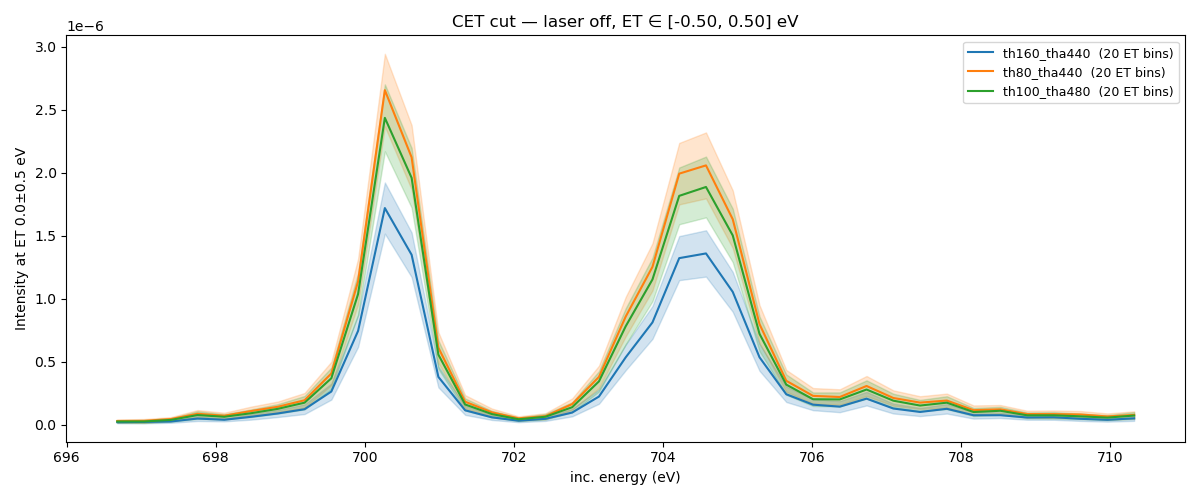

In [26]:


# Usage:
# elastic line (ET = 0)
plot_CET(avg_results, ET_center=0.0, ET_width=1, use='off')

# a specific Raman feature (e.g. dd-excitation around 3 eV ET)
# plot_CET(avg_results, ET_center=3.0, ET_width=0.5, use='off')

# pump-induced change at 3 eV ET
# plot_CET(avg_results, ET_center=3.0, ET_width=0.5, use='diff')

[-8.93617000e-02  7.35308511e+02]


/sdf/data/lcls/ds/rix/rix101231825/results/Zhaoyuan/DataAcceleratorChemRIXS/src/chemrixs/utils.py:455: RuntimeWarning: Mean of empty slice
  data_trans[ii,i] = np.nanmean(data[ii, mask])
/sdf/data/lcls/ds/rix/rix101231825/results/Zhaoyuan/DataAcceleratorChemRIXS/src/chemrixs/utils.py:456: RuntimeWarning: invalid value encountered in scalar divide
  std_trans[ii,i] = np.sqrt(np.sum(std[ii, mask]**2)) / N


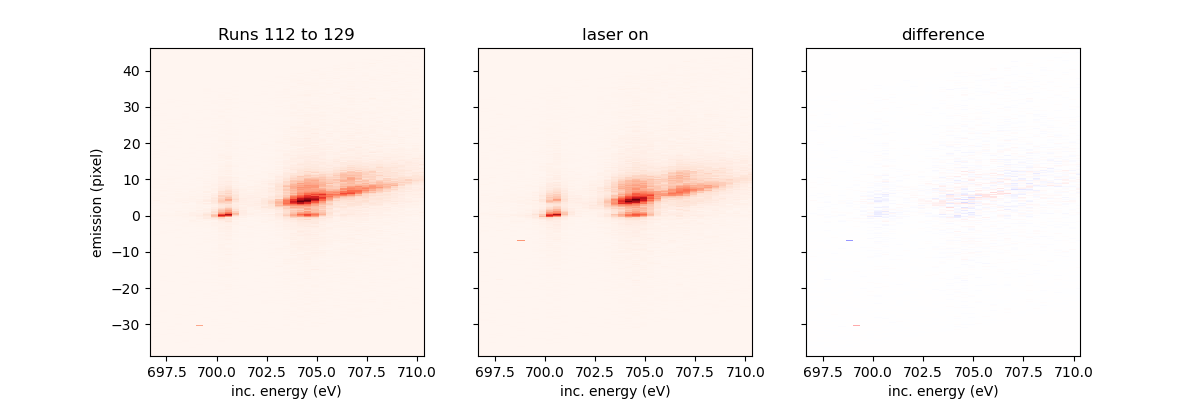

In [19]:
avg_results['th80_tha440'].plot_svls2D_ET(figsize=(12,4),savefig=False)

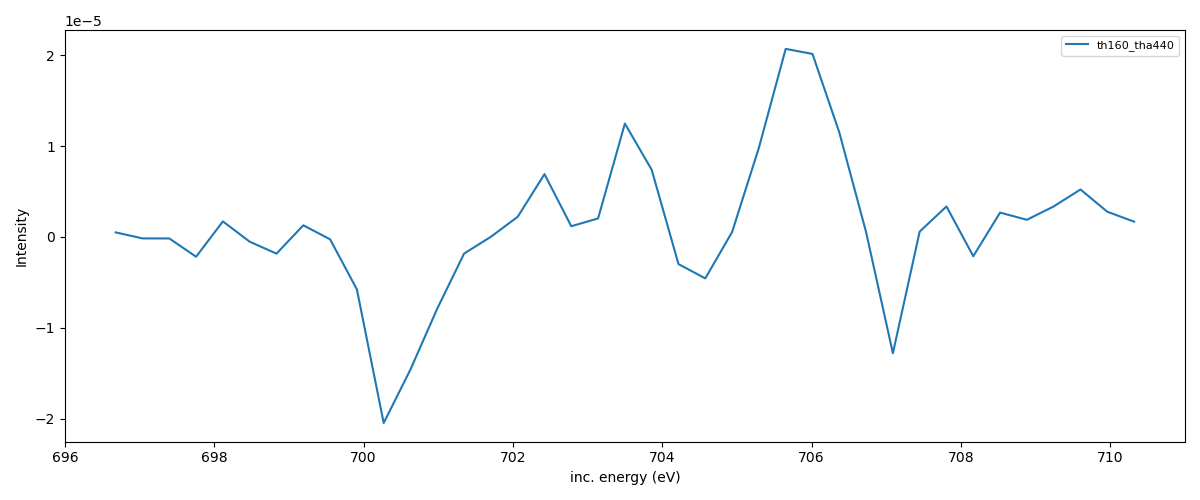

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
for tag, avg in avg_results.items():
        a = avg.average
    # make sure PFYs exist (get_PFYs populates PFY_*_mean / PFY_*_std)
        if 'PFY_on_std' not in a:
            avg.get_PFYs()
            a = avg.average

        scanvar = a['scanvar_off']
        dPFYerr = np.sqrt(a['PFY_on_std']**2 + a['PFY_off_std']**2)
        ax.plot(scanvar, a['PFY_on_mean'] - a['PFY_off_mean'], label=tag)
        # ax.plot(scanvar, dPFYerr, label=f'{tag} error', ls='--')

ax.set_xlabel('inc. energy (eV)')
ax.set_ylabel('Intensity')
# ax.set_title('dPFY error vs droplet threshold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

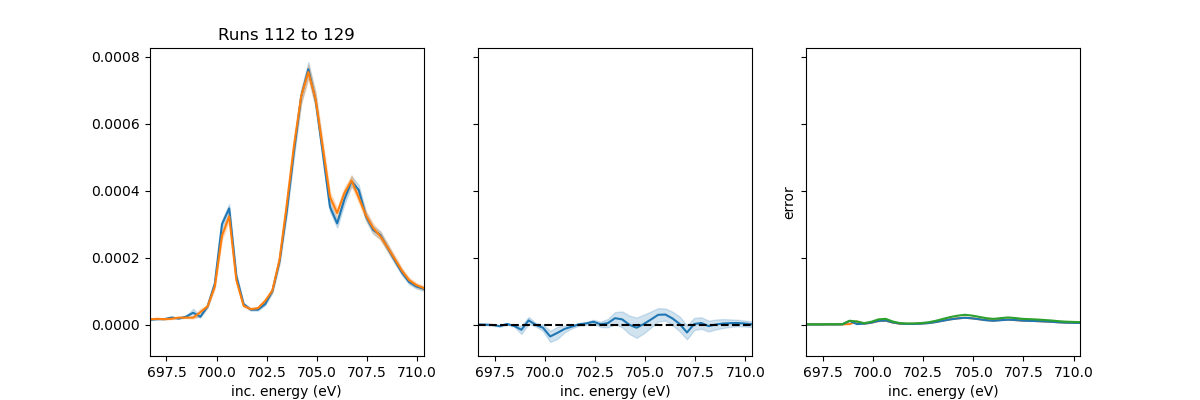

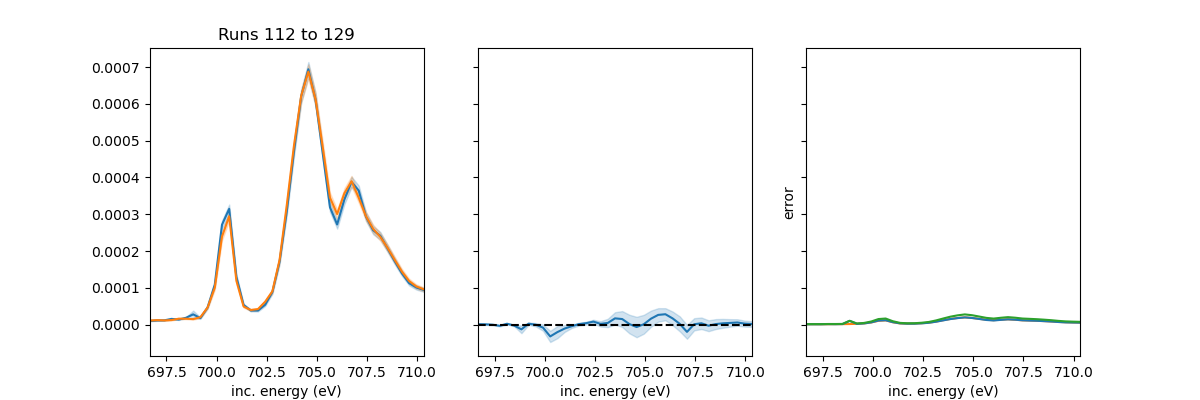

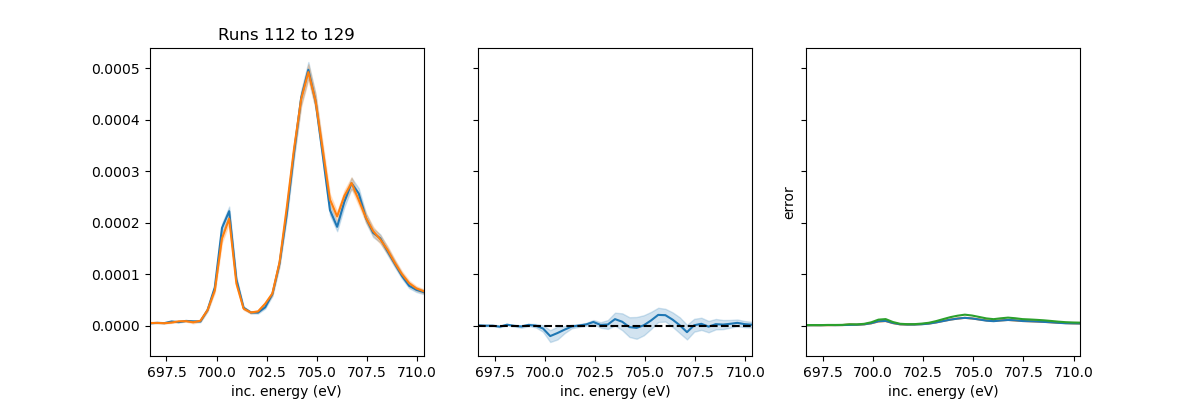

In [24]:
avg_results['th80_tha440'].plot_svls1D(figsize=(12,4))
avg_results['th100_tha480'].plot_svls1D(figsize=(12,4))
avg_results['th160_tha440'].plot_svls1D(figsize=(12,4))


for plotting avg of a few runs using different noise/adu threshold

In [5]:
base_folder = '/sdf/data/lcls/ds/rix/'
exp = 'rix101231825'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run0086.h5'
fyaml = '../roi_input.yml'
bgyaml = '../BGroi_input.yml'

runs = [112,115,116,117,118,119,120,121,122,123,127,129]
variant_tags = ['th160_tha440','th80_tha440','th100_tha480']

os.makedirs('proc', exist_ok=True)
os.makedirs('avg', exist_ok=True)

avg_results = {}
for tag in variant_tags:
    print(f'\n===== variant {tag} =====')
    variant_dir = f'proc_variants/{tag}'
    os.makedirs(variant_dir, exist_ok=True)

    # --- reduce every run for this variant ---
    for RUN in runs:
        variant_h5 = f'{base_folder}/{exp}/hdf5/smalldata/run{RUN}_{tag}/{exp}_Run{RUN:04d}.h5'
        proc_file  = f'{variant_dir}/Run{RUN:04d}.h5'

        if not os.path.isfile(proc_file):
            if not os.path.isfile(variant_h5):
                print(f'  !! MISSING raw file, skipping: {variant_h5}')
                continue
            print(f'  reducing run {RUN} ...')
            Reduced(variant_h5, bgname, fyaml, bgyaml,
                    save=True, scantype='mono_fly', norm=True)
            # Reduced always writes ./proc/RunXXXX.h5 — move it into the variant folder
            shutil.move(f'./proc/Run{RUN:04d}.h5', proc_file)
            print(f'    saved -> {proc_file}')
        else:
            print(f'  run {RUN} already reduced -> {proc_file}')

    # --- average all runs for this variant ---
    # Average reads proc_path + f'{run:04d}.h5' for each run in `runs`,
    # so all proc files must sit in variant_dir named RunXXXX.h5  (they do)
    avg = Average(runs, proc_path=f'{variant_dir}/Run', avg='mean',
                  output_path=f'avg/{runs[0]}_to_{runs[-1]}_{tag}.h5',
                  raw_path=f'{base_folder}/{exp}/hdf5/smalldata/REPLACED_BELOW',
                  bgpath=bgname, fyaml=fyaml, bgyaml=bgyaml,
                  save=True, norm=True, scantype='mono_fly')
    avg_results[tag] = avg
    print(f'  averaged {len(runs)} runs for {tag}')


===== variant th160_tha440 =====
  run 112 already reduced -> proc_variants/th160_tha440/Run0112.h5
  run 115 already reduced -> proc_variants/th160_tha440/Run0115.h5
  run 116 already reduced -> proc_variants/th160_tha440/Run0116.h5
  run 117 already reduced -> proc_variants/th160_tha440/Run0117.h5
  run 118 already reduced -> proc_variants/th160_tha440/Run0118.h5
  run 119 already reduced -> proc_variants/th160_tha440/Run0119.h5
  run 120 already reduced -> proc_variants/th160_tha440/Run0120.h5
  run 121 already reduced -> proc_variants/th160_tha440/Run0121.h5
  run 122 already reduced -> proc_variants/th160_tha440/Run0122.h5
  run 123 already reduced -> proc_variants/th160_tha440/Run0123.h5
  run 127 already reduced -> proc_variants/th160_tha440/Run0127.h5
  run 129 already reduced -> proc_variants/th160_tha440/Run0129.h5
[112. 193. 202. 202. 202. 208. 209. 200. 202. 196. 206. 199. 197. 207.
 205. 205. 208. 197. 201. 203. 197. 195. 200. 206. 205. 189. 200. 200.
 189. 195. 202. 191.


=== 1 runs (mode=diff): just added 112 → [112] ===
[112. 192. 202. 202. 202. 208. 209. 200. 202. 196. 206. 199. 197. 207.
 205. 205. 208. 197. 201. 203. 197. 195. 200. 206. 205. 189. 200. 200.
 189. 195. 202. 191. 193. 204. 193. 194. 196. 194. 189.]
  despeckle [axis_svls_off_mean]: kernel=3, n_sigma=10 -> flagged 58 pixels (0.187%)
  despeckle [axis_svls_on_mean]: kernel=3, n_sigma=10 -> flagged 61 pixels (0.196%)
  despeckle TOTAL: 119 pixels across 2 map(s)
saving data in ./avg/Run0112to0112.h5
dict_keys(['axis_svls_off_mean', 'axis_svls_off_std', 'axis_svls_off_sum', 'axis_svls_on_mean', 'axis_svls_on_std', 'axis_svls_on_sum', 'counts_off', 'counts_on', 'scanvar_off', 'scanvar_on', 'PFY_on_mean', 'PFY_on_std', 'PFY_off_mean', 'PFY_off_std'])
  |signal|=6.605e-06   noise=1.514e-05   SNR=0.436

=== 2 runs (mode=diff): just added 114 → [112, 114] ===
[112. 192. 202. 202. 202. 208. 209. 200. 202. 196. 206. 199. 197. 207.
 205. 205. 208. 197. 201. 203. 197. 195. 200. 206. 205. 189. 200

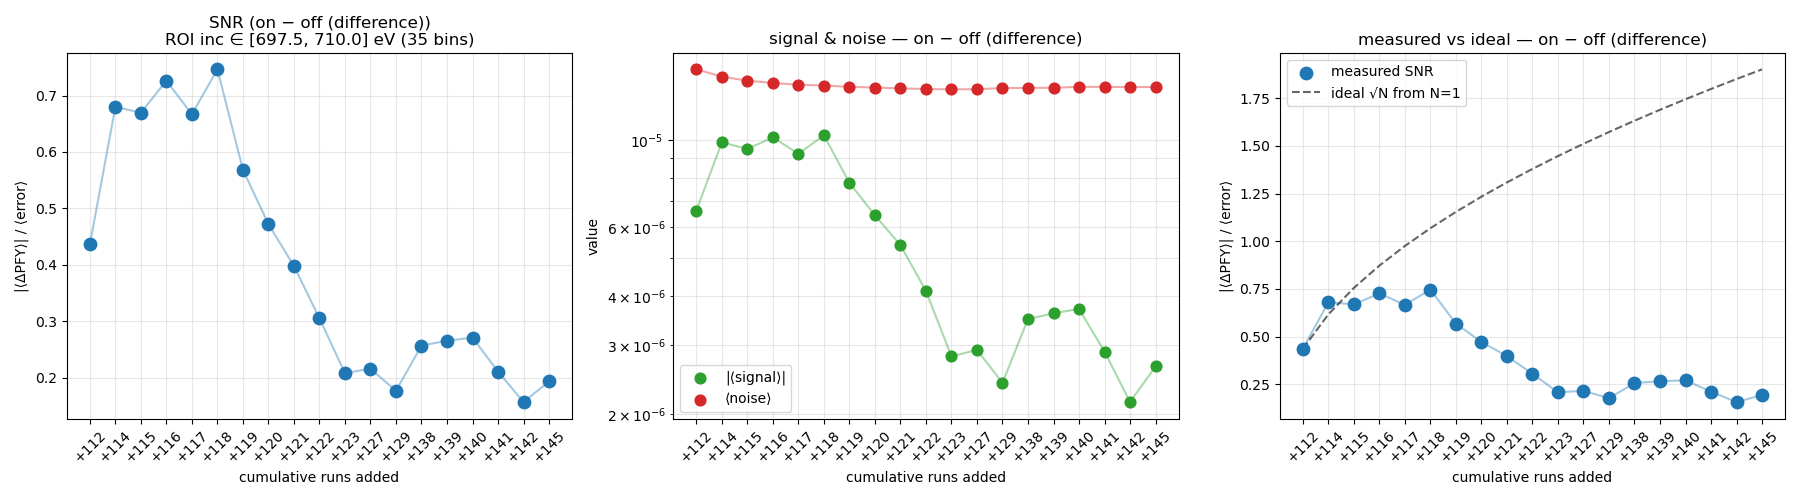


=== Per-run SNR changes (mode = diff) ===
step  new run        SNR      ΔSNR
1     112          0.436         -
2     114          0.680    +0.244
3     115          0.670    -0.010  ✗
4     116          0.726    +0.057
5     117          0.667    -0.059  ✗
6     118          0.746    +0.080
7     119          0.569    -0.178  ✗
8     120          0.472    -0.096  ✗
9     121          0.398    -0.074  ✗
10    122          0.305    -0.093  ✗
11    123          0.208    -0.097  ✗
12    127          0.216    +0.008
13    129          0.177    -0.039  ✗
14    138          0.257    +0.080
15    139          0.266    +0.009
16    140          0.271    +0.005
17    141          0.211    -0.060  ✗
18    142          0.157    -0.054  ✗
19    145          0.194    +0.037


In [5]:
base_folder = '/sdf/data/lcls/ds/rix/'
exp = 'rix101231825'
bgrun = 86
fyaml = '../roi_input.yml'
bgyaml = '../BGroi_input.yml'
bgname = f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run{bgrun:04d}.h5'

runs = [112,114,115,116,117,118,119,120,121,122,123,127,129,138,139,140,141,142,145]
# runs = [112,114,115,116,118,138]

# Incident-energy ROI around the feature of interest (A-peak GSB)
inc_roi = (697.5, 710.0)   # eV — adjust to bracket the feature in your data

# Which signal to evaluate: 'diff', 'off', or 'on'
mode = 'diff'

os.makedirs('avg', exist_ok=True)

# === Compute SNR for one subset, in the chosen mode ===
def compute_snr(runs_subset, inc_roi, mode):
    """
    Run Average over a subset, return SNR in the ROI for the chosen mode.
    
    mode='diff' -> |mean(PFY_on - PFY_off)| / mean(sqrt(std_on^2 + std_off^2))
    mode='off'  -> mean(PFY_off) / mean(PFY_off_std)
    mode='on'   -> mean(PFY_on)  / mean(PFY_on_std)
    """
    if mode not in ('diff', 'off', 'on'):
        raise ValueError(f"mode must be 'diff', 'off', or 'on', got {mode!r}")

    avg = Average(runs_subset, proc_path='proc/Run', avg='mean',
                  output_path=f'avg/cumulative_{len(runs_subset)}.h5',
                  raw_path=f'{base_folder}/{exp}/hdf5/smalldata/{exp}_Run',
                  bgpath=bgname, fyaml=fyaml, bgyaml=bgyaml,
                  save=True, norm=True)
    a = avg.average
    if 'PFY_on_mean' not in a:
        avg.get_PFYs()
        a = avg.average

    # ROI mask uses scanvar_off (same as scanvar_on, just pick one)
    inc = np.asarray(a['scanvar_off'])
    mask = (inc >= inc_roi[0]) & (inc <= inc_roi[1])
    if mask.sum() == 0:
        raise ValueError(f'No incident-energy bins in ROI {inc_roi}')

    if mode == 'diff':
        sig_trace = a['PFY_on_mean'] - a['PFY_off_mean']
        err_trace = np.sqrt(a['PFY_on_std']**2 + a['PFY_off_std']**2)
    elif mode == 'off':
        sig_trace = a['PFY_off_mean']
        err_trace = a['PFY_off_std']
    else:  # 'on'
        sig_trace = a['PFY_on_mean']
        err_trace = a['PFY_on_std']

    # |mean signal| / mean error in ROI
    signal = np.abs(np.nanmean(sig_trace[mask]))
    noise  = np.nanmean(err_trace[mask])
    return signal / noise, signal, noise, mask.sum()


# === Cumulative loop ===
snr_list, signal_list, noise_list = [], [], []
n_bins_in_roi = None

for k in range(1, len(runs) + 1):
    subset = runs[:k]
    print(f'\n=== {k} runs (mode={mode}): just added {subset[-1]} → {subset} ===')
    snr, signal, noise, n_bins = compute_snr(subset, inc_roi, mode)
    snr_list.append(snr)
    signal_list.append(signal)
    noise_list.append(noise)
    n_bins_in_roi = n_bins
    print(f'  |signal|={signal:.3e}   noise={noise:.3e}   SNR={snr:.3f}')

snr_arr = np.array(snr_list)
signal_arr = np.array(signal_list)
noise_arr = np.array(noise_list)

# === Plots ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(1, len(runs) + 1)
xlabels = [f'+{r}' for r in runs]

mode_label = {'diff': 'on − off (difference)',
              'off':  'laser off',
              'on':   'laser on'}[mode]
ratio_label = {'diff': '|⟨ΔPFY⟩| / ⟨error⟩',
               'off':  '⟨PFY_off⟩ / ⟨error_off⟩',
               'on':   '⟨PFY_on⟩ / ⟨error_on⟩'}[mode]

# SNR vs cumulative N
ax = axes[0]
ax.scatter(x, snr_arr, s=80, c='tab:blue', zorder=3)
ax.plot(x, snr_arr, c='tab:blue', alpha=0.4)
ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=45)
ax.set_xlabel('cumulative runs added'); ax.set_ylabel(ratio_label)
ax.set_title(f'SNR ({mode_label})\n'
             f'ROI inc ∈ [{inc_roi[0]}, {inc_roi[1]}] eV ({n_bins_in_roi} bins)')
ax.grid(alpha=0.3)

# Signal & noise separately
ax = axes[1]
ax.scatter(x, signal_arr, s=60, c='tab:green', label='|⟨signal⟩|', zorder=3)
ax.plot(x, signal_arr, c='tab:green', alpha=0.4)
ax.scatter(x, noise_arr, s=60, c='tab:red', label='⟨noise⟩', zorder=3)
ax.plot(x, noise_arr, c='tab:red', alpha=0.4)
ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=45)
ax.set_xlabel('cumulative runs added'); ax.set_ylabel('value')
ax.set_yscale('log')
ax.set_title(f'signal & noise — {mode_label}')
ax.legend(); ax.grid(alpha=0.3, which='both')

# Measured vs ideal √N
ax = axes[2]
ax.scatter(x, snr_arr, s=80, c='tab:blue', label='measured SNR', zorder=3)
ax.plot(x, snr_arr, c='tab:blue', alpha=0.4)
ideal = snr_arr[0] * np.sqrt(x / x[0])
ax.plot(x, ideal, 'k--', alpha=0.6, label='ideal √N from N=1')
ax.set_xticks(x); ax.set_xticklabels(xlabels, rotation=45)
ax.set_xlabel('cumulative runs added'); ax.set_ylabel(ratio_label)
ax.set_title(f'measured vs ideal — {mode_label}')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# === Per-run change table ===
print(f'\n=== Per-run SNR changes (mode = {mode}) ===')
print(f'{"step":<6}{"new run":<10}{"SNR":>8}{"ΔSNR":>10}')
for i, r in enumerate(runs):
    if i == 0:
        print(f'{i+1:<6}{r:<10}{snr_arr[i]:>8.3f}{"-":>10}')
    else:
        d = snr_arr[i] - snr_arr[i-1]
        marker = '  ✗' if d < 0 else ''
        print(f'{i+1:<6}{r:<10}{snr_arr[i]:>8.3f}{d:>+10.3f}{marker}')

th160_tha440:  mean=+4.9769e-09   std=1.9389e-08   (1904 pixels, 17 inc bins × 112 emi pixels)
th80_tha440:  mean=+1.7245e-08   std=3.1191e-08   (1904 pixels, 17 inc bins × 112 emi pixels)
th100_tha480:  mean=+1.1068e-08   std=2.6282e-08   (1904 pixels, 17 inc bins × 112 emi pixels)


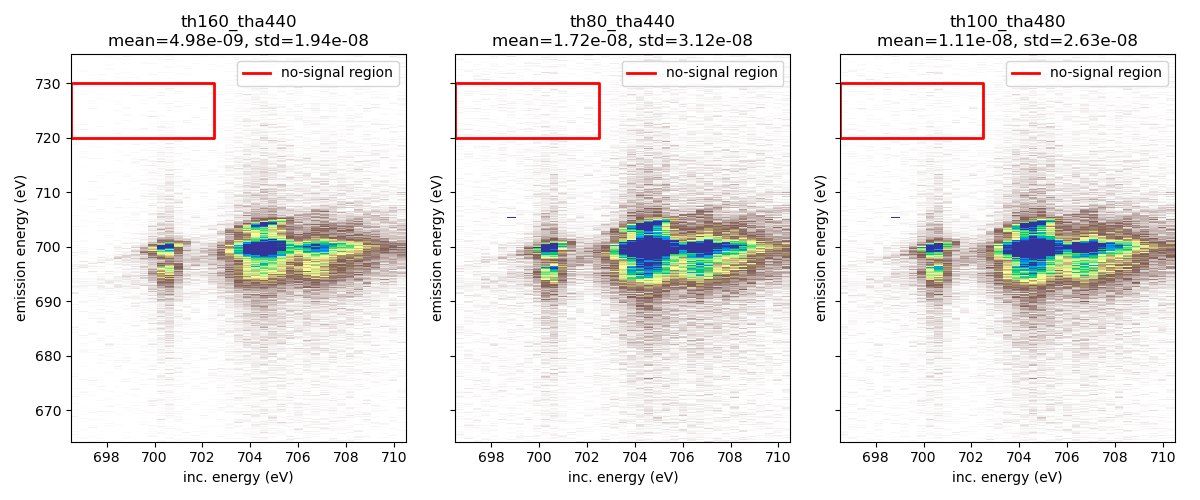

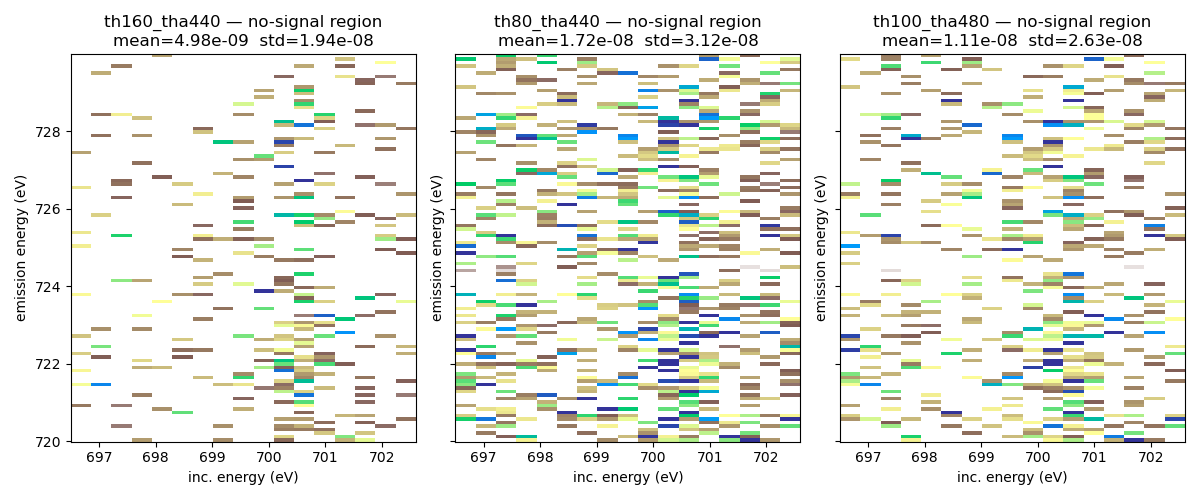

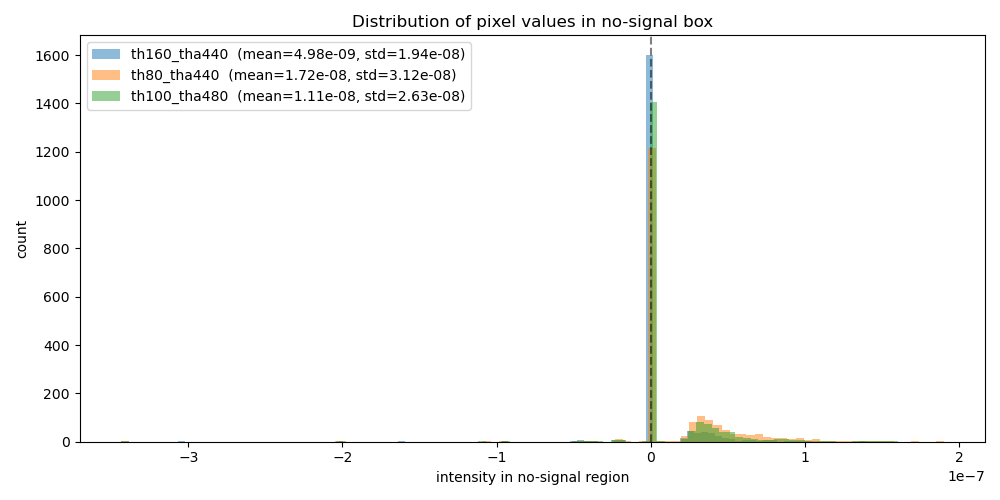


=== Summary: lower mean and std = cleaner noise rejection ===
variant                        mean            std
th160_tha440            +4.9769e-09     1.9389e-08
th80_tha440             +1.7245e-08     3.1191e-08
th100_tha480            +1.1068e-08     2.6282e-08


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# === Region where there should be no real RIXS signal ===
# inc_range = (699.5,701.2)
inc_range = (696.5, 702.5)   # incident energy window (eV)
emi_range = (720.0, 730.0)   # emission energy window (eV)
# emi_range = (690.0, 692.0)   # emission energy window (eV) --- IGNORE ---

# === Extract the region and compute statistics ===
results = {}
for tag, avg in avg_results.items():
    a = avg.average

    # incident energy axis (scanvar) and 2D map
    inc = np.asarray(a['scanvar_off'])
    Z = np.asarray(a['axis_svls_off_mean'])   # shape (n_inc, n_pix)

    # emission axis from calibration
    emi = avg.get_emi()

    # masks for the no-signal box
    inc_mask = (inc >= inc_range[0]) & (inc <= inc_range[1])
    emi_mask = (emi >= emi_range[0]) & (emi <= emi_range[1])

    # extract the box
    sub = Z[np.ix_(inc_mask, emi_mask)]

    # stats
    mean_val = np.nanmean(sub)
    std_val  = np.nanstd(sub)
    n_pix = sub.size

    results[tag] = {
        'Z': Z, 'inc': inc, 'emi': emi,
        'inc_mask': inc_mask, 'emi_mask': emi_mask,
        'sub': sub, 'mean': mean_val, 'std': std_val, 'n': n_pix,
    }

    print(f'{tag}:  mean={mean_val:+.4e}   std={std_val:.4e}   '
          f'({n_pix} pixels, '
          f'{inc_mask.sum()} inc bins × {emi_mask.sum()} emi pixels)')

# === Plot the full RIXS map of each variant, with the no-signal box overlaid ===
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(4*n, 5), sharex=True, sharey=True)
if n == 1:
    axes = [axes]

vmax = np.nanpercentile(np.concatenate([r['Z'].ravel() for r in results.values()]), 99)
for ax, (tag, r) in zip(axes, results.items()):
    im = ax.pcolormesh(r['inc'], r['emi'], r['Z'].T,
                       cmap='terrain_r', vmin=0, vmax=vmax)
    # overlay the no-signal box
    ax.plot([inc_range[0], inc_range[1], inc_range[1], inc_range[0], inc_range[0]],
            [emi_range[0], emi_range[0], emi_range[1], emi_range[1], emi_range[0]],
            'r-', lw=2, label='no-signal region')
    ax.set_xlabel('inc. energy (eV)')
    ax.set_ylabel('emission energy (eV)')
    ax.set_title(f'{tag}\nmean={r["mean"]:.2e}, std={r["std"]:.2e}')
    ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

# === Zoom-in on just the no-signal region for each variant ===
fig, axes = plt.subplots(1, n, figsize=(4*n, 5), sharey=True)
if n == 1:
    axes = [axes]
zoom_vmax = np.nanpercentile(np.concatenate([r['sub'].ravel() for r in results.values()]), 99)
for ax, (tag, r) in zip(axes, results.items()):
    inc_sub = r['inc'][r['inc_mask']]
    emi_sub = r['emi'][r['emi_mask']]
    ax.pcolormesh(inc_sub, emi_sub, r['sub'].T,
                  cmap='terrain_r', vmin=0, vmax=zoom_vmax)
    ax.set_xlabel('inc. energy (eV)')
    ax.set_ylabel('emission energy (eV)')
    ax.set_title(f'{tag} — no-signal region\nmean={r["mean"]:.2e}  std={r["std"]:.2e}')
plt.tight_layout()
plt.show()

# === Histograms of the pixel values in the no-signal region ===
fig, ax = plt.subplots(figsize=(10, 5))
for tag, r in results.items():
    vals = r['sub'].ravel()
    vals = vals[~np.isnan(vals)]
    ax.hist(vals, bins=100, alpha=0.5,
            label=f'{tag}  (mean={r["mean"]:.2e}, std={r["std"]:.2e})')
ax.axvline(0, color='k', ls='--', alpha=0.5)
ax.set_xlabel('intensity in no-signal region')
ax.set_ylabel('count')
# ax.set_yscale('log')
ax.set_title('Distribution of pixel values in no-signal box')
ax.legend()
plt.tight_layout()
plt.show()

# === Summary ===
print('\n=== Summary: lower mean and std = cleaner noise rejection ===')
print(f'{"variant":<20} {"mean":>14} {"std":>14}')
for tag, r in results.items():
    print(f'{tag:<20} {r["mean"]:>+14.4e} {r["std"]:>14.4e}')